In [1]:
%matplotlib inline
import matplotlib.pyplot as plt 
import numpy as np
import pickle
import pandas as pd

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Bidirectional, RepeatVector, Dropout, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow import keras

## Load data

In [2]:
import tensorflow as tf
import tensorflow_addons as tfa
import time

### Load and preprocess the data

In [3]:
with open('data/preprocessed/dicts.pkl', 'rb') as fin:
    conversion_dicts = pickle.load(fin)

In [4]:
with open('data/preprocessed/input_seqs_train.txt') as fin:
    input_seqs_train = fin.readlines()
    input_seqs_train = [s.strip() for s in input_seqs_train]
        
with open('data/preprocessed/output_seqs_train.txt') as fin:
    output_seqs_train = fin.readlines()
    output_seqs_train = [s.strip() for s in output_seqs_train]
        
with open('data/preprocessed/input_seqs_test.txt') as fin:
    input_seqs_test = fin.readlines()
    input_seqs_test = [s.strip() for s in input_seqs_test]
        
with open('data/preprocessed/output_seqs_test.txt') as fin:
    output_seqs_test = fin.readlines()
    output_seqs_test = [s.strip() for s in output_seqs_test]

for now, only take unique input-output combinations. This reduces the dataset quite a bit.

In [5]:
input_seqs_train_uq, output_seqs_train_uq = zip(*set(list(zip(input_seqs_train, output_seqs_train))))

In [6]:
input_seqs_test_uq, output_seqs_test_uq = zip(*set(list(zip(input_seqs_test, output_seqs_test))))

In [7]:
len(input_seqs_train), len(input_seqs_train_uq)

(269539, 49402)

In [8]:
## Add <start> and <end> chars
if '<start>' not in conversion_dicts['input_char2idx']:
    idx = len(conversion_dicts['input_char2idx'])
    conversion_dicts['input_char2idx']['<start>'] = idx
    conversion_dicts['input_idx2char'][idx] = '<start>'

if '<end>' not in conversion_dicts['input_char2idx']:
    idx = len(conversion_dicts['input_char2idx'])
    conversion_dicts['input_char2idx']['<end>'] = idx
    conversion_dicts['input_idx2char'][idx] = '<end>'
    
if '<start>' not in conversion_dicts['output_char2idx']:
    idx = len(conversion_dicts['output_char2idx'])
    conversion_dicts['output_char2idx']['<start>'] = idx
    conversion_dicts['output_idx2char'][idx] = '<start>'

if '<end>' not in conversion_dicts['output_char2idx']:
    idx = len(conversion_dicts['output_char2idx'])
    conversion_dicts['output_char2idx']['<end>'] = idx
    conversion_dicts['output_idx2char'][idx] = '<end>'

In [9]:
def preprocess_sequences(seqs, char2idx, max_len):
    seqs = [['<start>'] + [c for c in seq] + ['<end>'] for seq in seqs]
    inputs = [[char2idx[c] for c in seq] for seq in seqs]
    inputs = tf.keras.preprocessing.sequence.pad_sequences(inputs,
                                                          maxlen=max_len,
                                                          padding='post',
                                                          value=char2idx['PAD'])
    return inputs

In [10]:
max_length_input = max([len(s) for s in input_seqs_train]) + 2
max_length_output = max([len(s) for s in output_seqs_train]) + 2

In [11]:
X_train = preprocess_sequences(input_seqs_train_uq, conversion_dicts['input_char2idx'], max_length_input)
y_train = preprocess_sequences(output_seqs_train_uq, conversion_dicts['output_char2idx'], max_length_output)

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.025, random_state=0)

In [13]:
X_train.shape, y_train.shape

((48166, 25), (48166, 26))

In [14]:
X_val.shape, y_val.shape

((1236, 25), (1236, 26))

In [15]:
# Parameters
vocab_input_size = len(conversion_dicts['input_char2idx'].keys())
vocab_output_size = len(conversion_dicts['output_char2idx'].keys())
max_length_input = X_train.shape[1]
max_length_output = y_train.shape[1]

BATCH_SIZE = 32
embedding_dim = 30
hidden_dim = 50


## Define model

In [16]:
X_train.shape

(48166, 25)

In [17]:
encoder_inputs = Input(shape=(max_length_input,))
x = Embedding(vocab_input_size, embedding_dim)(encoder_inputs)
x, state_h, state_c = LSTM(hidden_dim,
                           return_state=True)(x)
encoder_states = [state_h, state_c]

# Set up the decoder, using `encoder_states` as initial state.
decoder_inputs = Input(shape=(None,))
decoder_embedding = Embedding(vocab_output_size, embedding_dim)
x = decoder_embedding(decoder_inputs)

decoder_lstm = LSTM(hidden_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(x, initial_state=encoder_states)

decoder_dense = Dense(vocab_output_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)
# Define the model that will turn
# `encoder_input_data` & `decoder_input_data` into `decoder_target_data`
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)


In [18]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 25)]         0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, None)]       0                                            
__________________________________________________________________________________________________
embedding (Embedding)           (None, 25, 30)       1050        input_1[0][0]                    
__________________________________________________________________________________________________
embedding_1 (Embedding)         (None, None, 30)     1290        input_2[0][0]                    
______________________________________________________________________________________________

In [19]:
encoder_input_data = X_train
y_train_onehot = keras.utils.to_categorical(y_train)
decoder_input_data = y_train[:,:-1]
decoder_target_data = y_train_onehot[:,1:,:]

In [20]:
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
EPOCHS = 20

history = model.fit([encoder_input_data, decoder_input_data], decoder_target_data,
          batch_size=BATCH_SIZE,
          epochs=EPOCHS,
          validation_split=0.05)

Epoch 1/20
1430/1430 [==============================] - 205s 143ms/step - loss: 0.9470 - accuracy: 0.7414 - val_loss: 0.7187 - val_accuracy: 0.7897
Epoch 2/20
1430/1430 [==============================] - 198s 138ms/step - loss: 0.6513 - accuracy: 0.8077 - val_loss: 0.5875 - val_accuracy: 0.8247
Epoch 3/20
1430/1430 [==============================] - 192s 134ms/step - loss: 0.5545 - accuracy: 0.8332 - val_loss: 0.5103 - val_accuracy: 0.8439
Epoch 4/20
1430/1430 [==============================] - 173s 121ms/step - loss: 0.4957 - accuracy: 0.8482 - val_loss: 0.4793 - val_accuracy: 0.8508
Epoch 5/20
1430/1430 [==============================] - 201s 140ms/step - loss: 0.4540 - accuracy: 0.8589 - val_loss: 0.4249 - val_accuracy: 0.8659
Epoch 6/20
1430/1430 [==============================] - 200s 140ms/step - loss: 0.4185 - accuracy: 0.8688 - val_loss: 0.4084 - val_accuracy: 0.8704
Epoch 7/20
1430/1430 [==============================] - 196s 137ms/step - loss: 0.3855 - accuracy: 0.8782 - val_

In [22]:
history_df = pd.DataFrame(history.history)

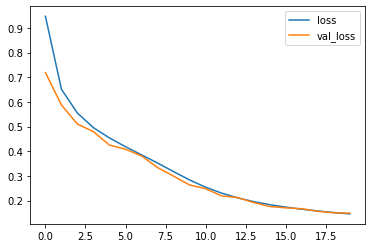

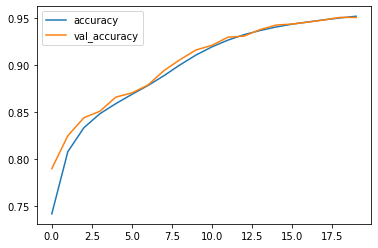

In [23]:
# Plot training process
history_df[['loss', 'val_loss']].plot()
plt.show()

history_df[['accuracy', 'val_accuracy']].plot()
plt.show()

## Define submodels: encoder and decoder
These are helpful when we want to run an example through the model

In [24]:
encoder_model = Model(encoder_inputs, encoder_states)

decoder_state_input_h = Input(shape=(hidden_dim,))
decoder_state_input_c = Input(shape=(hidden_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_outputs, state_h, state_c = decoder_lstm(
    decoder_embedding(decoder_inputs), initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs] + decoder_states)

In [25]:
encoder_model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 25)]              0         
_________________________________________________________________
embedding (Embedding)        (None, 25, 30)            1050      
_________________________________________________________________
lstm (LSTM)                  [(None, 50), (None, 50),  16200     
Total params: 17,250
Trainable params: 17,250
Non-trainable params: 0
_________________________________________________________________


In [26]:
decoder_model.summary()

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, None)]       0                                            
__________________________________________________________________________________________________
embedding_1 (Embedding)         (None, None, 30)     1290        input_2[0][0]                    
__________________________________________________________________________________________________
input_3 (InputLayer)            [(None, 50)]         0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 50)]         0                                            
____________________________________________________________________________________________

## Different methods of decoding the sentences

In [27]:
import tensorflow_addons as tfa

In [28]:
def array2seq(a, idx2char):
    seq = [idx2char[i] for i in a]
    seq = seq[:seq.index('<end>')]
    seq = ''.join(seq)
    return seq

In [29]:
START_IDX = conversion_dicts['output_char2idx']['<start>']
END_IDX = conversion_dicts['output_char2idx']['<end>']

def decode_greedy(inputs):
    inference_batch_size = inputs.shape[0]
    start_tokens = tf.fill([inference_batch_size], START_IDX)
    end_token = END_IDX

    # Instantiate BasicDecoder object
    greedy_sampler = tfa.seq2seq.GreedyEmbeddingSampler()
    decoder_instance = tfa.seq2seq.BasicDecoder(cell=decoder_lstm.cell, sampler=greedy_sampler, output_layer=decoder_dense)

    # First run encoder
    encoder_h, encoder_c = encoder_model.predict(inputs)
    initial_state = [tf.constant(encoder_h), tf.constant(encoder_c)] #decoder_lstm.cell.get_initial_state(batch_size=inference_batch_size, dtype=tf.float32)#.clone(states_value)
    
    decoder_embedding_matrix = decoder_embedding.variables[0]
    outputs, _, _ = decoder_instance(decoder_embedding_matrix, 
                                 start_tokens = start_tokens, 
                                 end_token= end_token, 
                                 initial_state=initial_state)
    return outputs, outputs.sample_id.numpy()

In [30]:
def decode_beam(inputs, beam_width):
    inference_batch_size = inputs.shape[0]
    start_tokens = tf.fill([inference_batch_size], START_IDX)
    end_token = END_IDX

    # Instantiate BEAMDecoder object
    decoder_instance = tfa.seq2seq.BeamSearchDecoder(cell=decoder_lstm.cell, beam_width=beam_width, output_layer=decoder_dense)

    decoder_embedding_matrix = decoder_embedding.variables[0]

    # First run encoder
    encoder_h, encoder_c = encoder_model.predict(inputs)

    hidden_state = tfa.seq2seq.tile_batch([encoder_h, encoder_c], multiplier=beam_width)
    decoder_initial_state = hidden_state

    outputs, final_state, sequence_lengths = decoder_instance(decoder_embedding_matrix, start_tokens=start_tokens, end_token=end_token, initial_state=decoder_initial_state)
    final_outputs = tf.transpose(outputs.predicted_ids, perm=(0,2,1))
    beam_scores = tf.transpose(outputs.beam_search_decoder_output.scores, perm=(0,2,1))

    return final_outputs.numpy(), beam_scores.numpy()

We show the result of the different decoders on a sample of the validation set

In [34]:
outputs, output_seqs = decode_greedy(X_val)
output_seqs_beam, output_scores_beam = decode_beam(X_val, 3)

for i in range(100):
    print('Input: ', array2seq(X_val[i][1:], conversion_dicts['input_idx2char']))
    print('True output:', array2seq(y_val[i][1:], conversion_dicts['output_idx2char']))
    print('Greedy: ', array2seq(output_seqs[i], conversion_dicts['output_idx2char']))
    for j in range(3):
        print('Beam {}: '.format(j), array2seq(output_seqs_beam[i,j,:], conversion_dicts['output_idx2char']))
    print()

Input:  L:MAV.@<;J
True output: L-MV</J
Greedy:  L-MV</J
Beam 0:  L-MV</J
Beam 1:  L-MV</+J
Beam 2:  L-!MV<[/+J

Input:  W:>@BIJ
True output: W->B/+J
Greedy:  W->B/+J
Beam 0:  W->B/+J
Beam 1:  W->B/+W
Beam 2:  W->B(H[/+J

Input:  <:AY@RANIJ
True output: <YR[+NJ
Greedy:  <YRN/J
Beam 0:  <YRN/J
Beam 1:  <YRN/+J
Beam 2:  <YR=/J+N

Input:  R:B@B@H
True output: RBB(H/H
Greedy:  RBB[H
Beam 0:  RBB[H
Beam 1:  !RBB[H=
Beam 2:  RBB(H/H

Input:  B.:RIS.@H
True output: B-RSH/
Greedy:  BRS[H
Beam 0:  BR+NW
Beam 1:  BRS[H
Beam 2:  BRS(H/H

Input:  W@>;PER
True output: W->PR/
Greedy:  Wn->!(H]PR(H[
Beam 0:  Wn->!RP(H[
Beam 1:  Wn->!(H]P(WR[
Beam 2:  Wn->!(H]PR(H[

Input:  >AM.;YW.
True output: !>MY[Wd
Greedy:  >!(H](NTR[W
Beam 0:  >MY[W
Beam 1:  >MY[Wd
Beam 2:  >!(N]MY(H[W

Input:  N:R@DIJM
True output: NRD/JM
Greedy:  NDR[/JM
Beam 0:  NRD/JM
Beam 1:  NDR/JM
Beam 2:  NDR[/JM

Input:  MA<:ANEH
True output: M!(H]<NH===[/a
Greedy:  M<NH/
Beam 0:  M<NH/
Beam 1:  M<NH=/
Beam 2:  M<N(H/H

Input:  J:K@N:J@

And we show accuraracy (of exactly correct outputs) use the greeedy decoder and beam decoder

In [35]:
def get_acc(predicted, gold):
    predicted_seq = np.array([array2seq(a, conversion_dicts['output_idx2char']) for a in predicted])
    gold_seq = np.array([array2seq(a[1:], conversion_dicts['output_idx2char']) for a in gold])
    return np.mean(predicted_seq == gold_seq)

In [36]:
val_acc = get_acc(output_seqs, y_val)
print('Validation acc greedy:', val_acc)

val_beam_acc = get_acc(output_seqs_beam[:,0,:], y_val)
print('Validation acc beam:', val_beam_acc)

Validation acc greedy: 0.3074433656957929
Validation acc beam: 0.2540453074433657
